In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import h5py
from datasets import ShapesDataset, DSpritesDataset

from utils import load_model
from models import VAE_dsprites, VAE_shapes

In [2]:
RESULTS_PATH = "./results"
DATASET = "3d_shapes" # dsprites / 3d_shapes
VAE_MODE = "default" # default / beta

if DATASET not in ["3d_shapes", "dsprites"]:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")

if VAE_MODE not in ["default", "beta"]:
    raise ValueError("VAE_MODE must be one of 'default', 'beta'")

LOAD_MODEL_DIR = f"{VAE_MODE}_VAE_{DATASET}"
CHAMPION_MODEL_NAME = "champion"

IMG_WIDTH_HEIGHT = 64
NO_CHANNELS = 1 if DATASET == "dsprites" else 3
DISENTANGLEMENT_RANGE = [-4, 4]
DISENTANGLEMENT_STEPS = 16

print("---SETTINGS---")
print(f"dataset: {DATASET}")
print(f"vae mode: {VAE_MODE}")
print(f"loading directory: {LOAD_MODEL_DIR}")

---SETTINGS---
dataset: 3d_shapes
vae mode: default
loading directory: default_VAE_3d_shapes


In [3]:
LATENT_DIM = 5 if DATASET == "dsprites" else 6 # changed 10 -> 5

hyperparameters = {
    "device": 'cuda' if torch.cuda.is_available() else 'cpu',
    "latent_dim": LATENT_DIM, # proposed value by FactorVAE paper
}

print("\n---HYPERPARAMETERS---")
for key, value in hyperparameters.items():
    print(f"{key}: {value}")


---HYPERPARAMETERS---
device: cuda
latent_dim: 6


# Show sample images

In [4]:
# LOADING
if DATASET == "dsprites":
    dataset_zip = np.load('./data/dsprites_64x64.npz')
    images = dataset_zip['imgs']
    n_samples = images.shape[0]

elif DATASET == "3d_shapes":
    shapes_dataset = h5py.File('./data/3d_shapes.h5', 'r')
    
    shapes_labels = shapes_dataset['labels']  # array shape [480000,6], float64
    batch_images = shapes_dataset['images']  # array shape [480000,64,64,3], uint8 in range(256)
    images = np.array(batch_images)
    
    shapes_image_shape = batch_images.shape[1:]  # [64,64,3]
    shapes_label_shape = shapes_labels.shape[1:]  # [6]
    n_samples = shapes_labels.shape[0]

else:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")

images_shuffled = images[np.random.permutation(n_samples)]

# CREATE DATALOADERS
if DATASET == "dsprites":
    loader = DataLoader(DSpritesDataset(images_shuffled), batch_size=16)

elif DATASET == "3d_shapes":
    loader = DataLoader(ShapesDataset(images_shuffled), batch_size=16)

else:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")

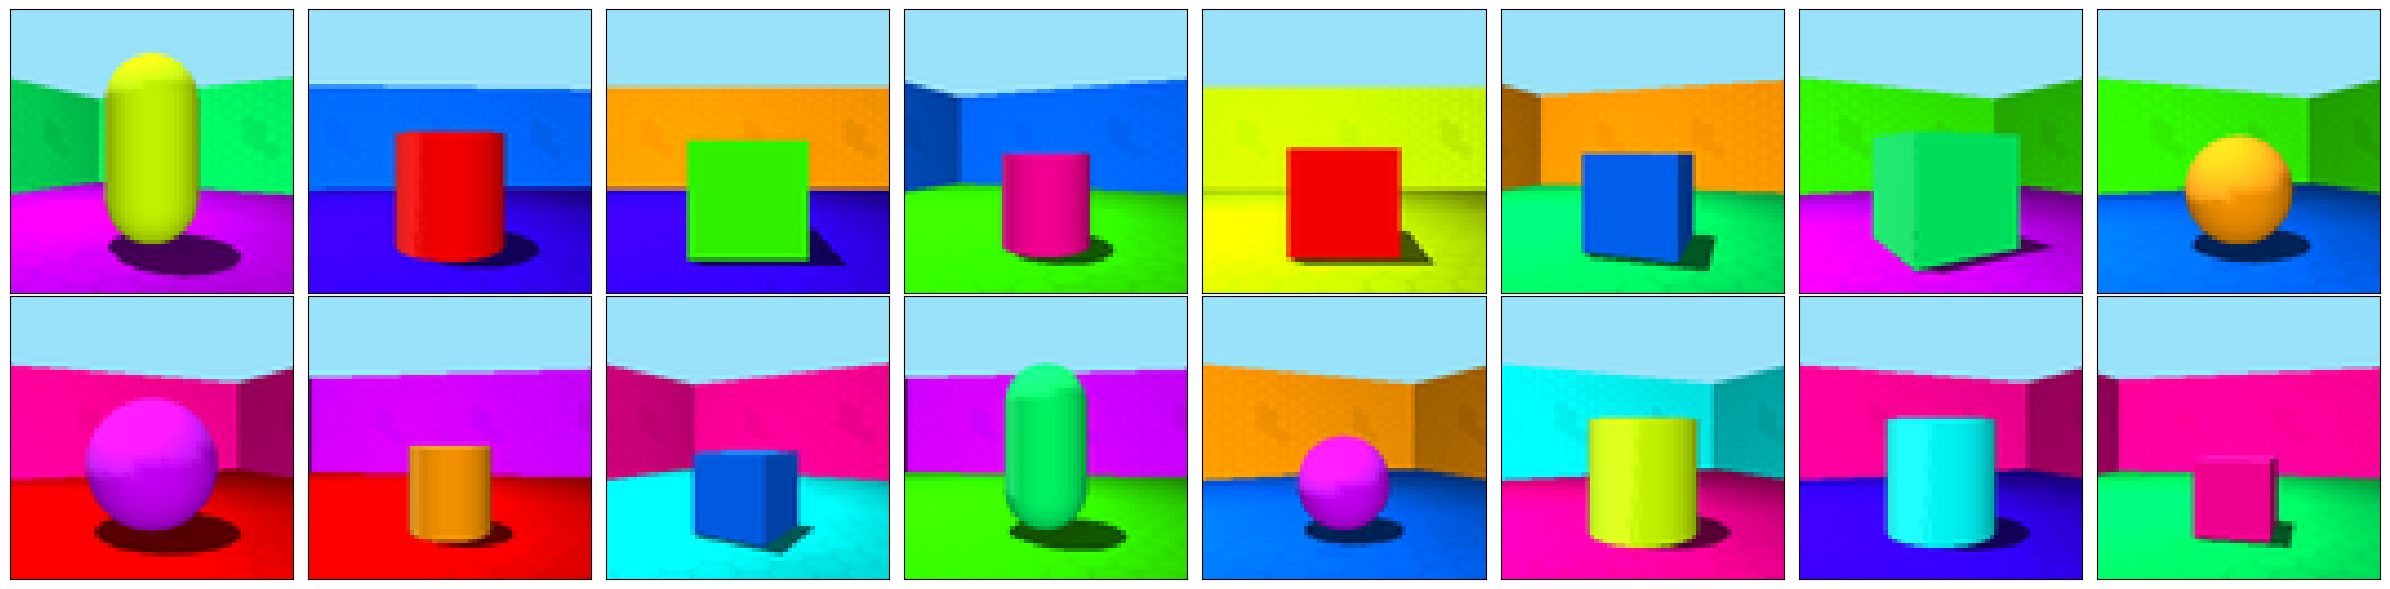

In [5]:
def show_images_grid(imgs):
    imgs = imgs.detach().cpu()
    ncols = 8
    nrows = 2
    _, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()

    for ax_i, ax in enumerate(axes):
        if ax_i < len(imgs):
            img = imgs[ax_i]

            if img.shape[0] == 3:  # RGB
                img = img.permute(1, 2, 0)  # CxHxW → HxWxC
                ax.imshow(img, interpolation='nearest')
            elif img.shape[0] == 1:  # Grayscale
                img = img.squeeze(0)  # 1xHxW → HxW
                ax.imshow(img, cmap='gray', interpolation='nearest')
            else:
                raise ValueError(f"Unerwartete Channel-Zahl: {img.shape[0]}")

            ax.set_xticks([])
            ax.set_yticks([])
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Get a batch of images
dataiter = iter(loader)
batch_images = next(dataiter)
show_images_grid(batch_images)

# Visualize Reconstruction

In [6]:
# Load model
path = os.path.join(RESULTS_PATH, LOAD_MODEL_DIR, f"{CHAMPION_MODEL_NAME}.pth")
if DATASET == "dsprites":
    model = load_model(VAE_dsprites(latent_dim=hyperparameters['latent_dim']), path=path, hyperparameters=hyperparameters).to(hyperparameters['device'])
elif DATASET == "3d_shapes":
    model = load_model(VAE_shapes(latent_dim=hyperparameters['latent_dim']), path=path, hyperparameters=hyperparameters).to(hyperparameters['device'])

Model loaded from ./results/default_VAE_3d_shapes/champion.pth


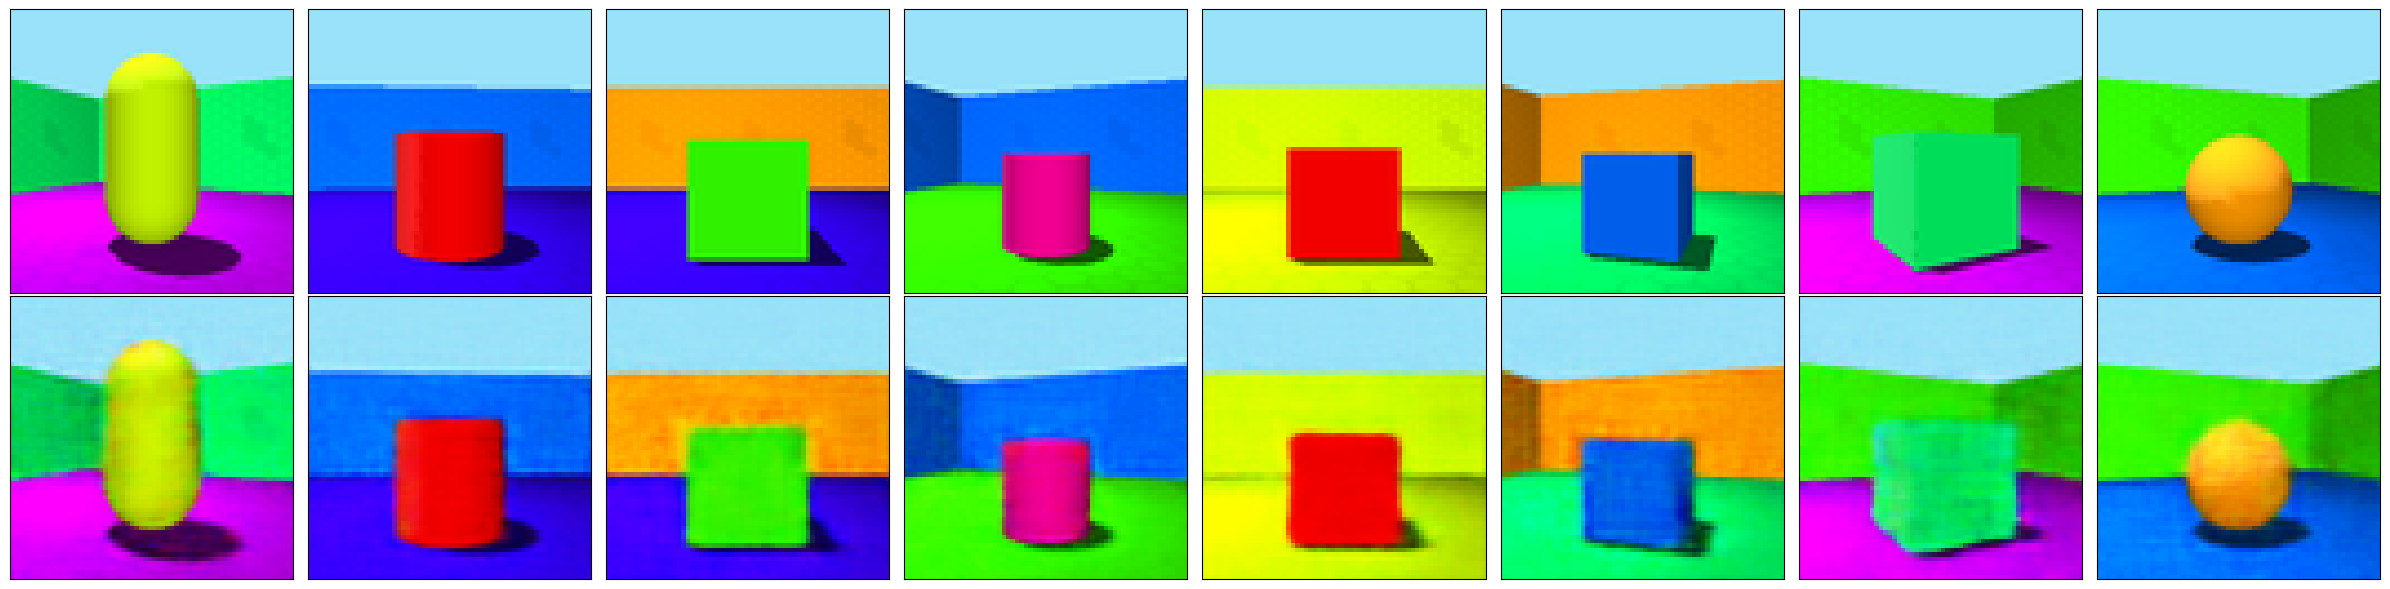

Original (top) vs. Reconstruction (bottom)


In [7]:
with torch.no_grad():
        data = batch_images.to(hyperparameters['device'])
        recon_batch, mu, logvar = model(data)
        comparison = torch.cat([data[:8], recon_batch.view(16, NO_CHANNELS, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT)[:8]])
        show_images_grid(comparison)

print("Original (top) vs. Reconstruction (bottom)")

# Latent Space Traversal

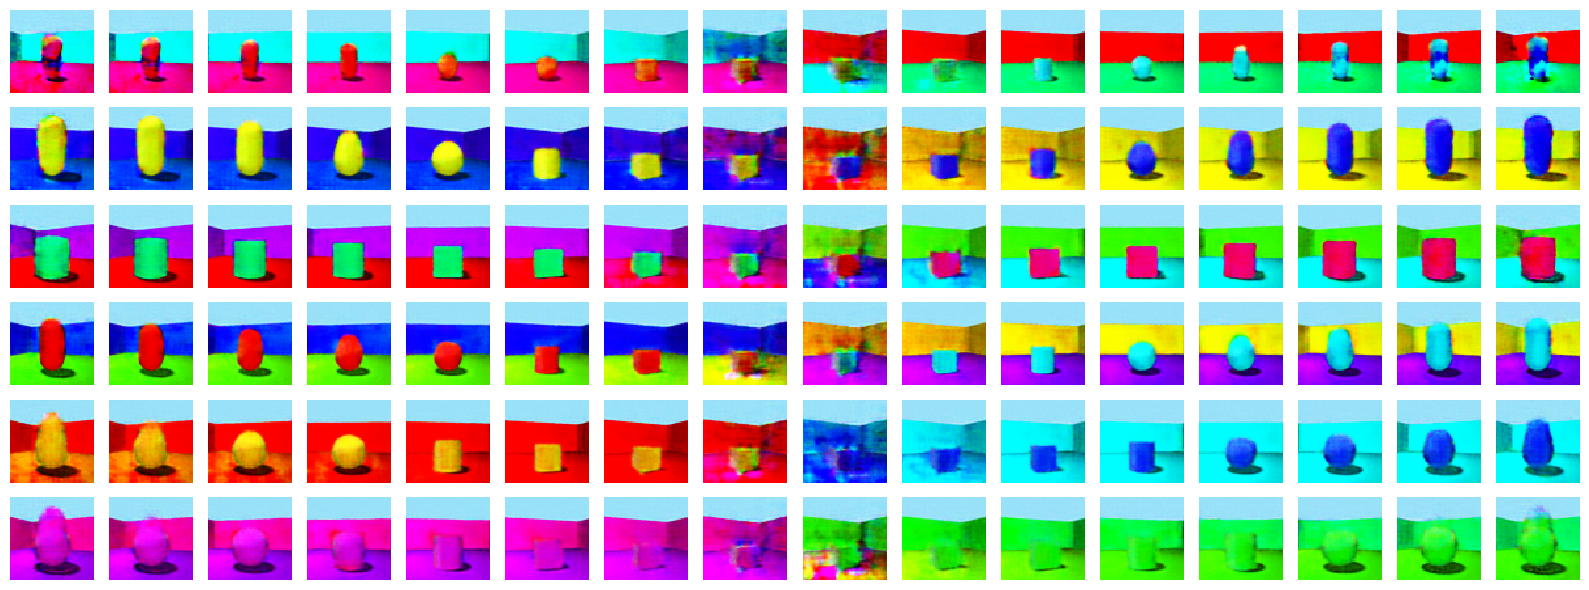

In [8]:
test_viz_imgs = []
with torch.no_grad():
    z = torch.zeros(hyperparameters['latent_dim'])
    for z_param in range(hyperparameters['latent_dim']):
        row_imgs = []
        for val in torch.linspace(DISENTANGLEMENT_RANGE[0], DISENTANGLEMENT_RANGE[1], DISENTANGLEMENT_STEPS): # tensor with DISENTANGLEMENT_STEPS values ranging from DISENTANGLEMENT_RANGE[0] to DISENTANGLEMENT_RANGE[1]
            z_copy = z.clone().to(hyperparameters['device']) 
            z_copy[z_param] = val  # change one dimension of latent vector
            img = model.decode(z_copy.unsqueeze(0)) # decode latent vector and add batch dimension
            row_imgs.append(img.view(NO_CHANNELS, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT).cpu().numpy()) 
        test_viz_imgs.append(row_imgs)
        

# Plot
fig, axes = plt.subplots(nrows=hyperparameters['latent_dim'], ncols=DISENTANGLEMENT_STEPS, figsize=(DISENTANGLEMENT_STEPS, hyperparameters['latent_dim']))

for dim in range(hyperparameters['latent_dim']):
    for step in range(DISENTANGLEMENT_STEPS):

        ax = axes[dim, step]

        # for RGB images
        if test_viz_imgs[dim][step].shape[0] == 3:
            test_viz_imgs[dim][step] = torch.tensor(test_viz_imgs[dim][step]).permute(1, 2, 0).numpy()  # CxHxW → HxWxC
            ax.imshow(test_viz_imgs[dim][step], interpolation='nearest')
        
        # for grayscale images
        elif test_viz_imgs[dim][step].shape[0] == 1:  # Grayscale
            test_viz_imgs[dim][step] = torch.tensor(test_viz_imgs[dim][step]).squeeze(0).numpy()  # 1xHxW → HxW
            ax.imshow(test_viz_imgs[dim][step], cmap='gray', interpolation='nearest')
        
        else:
            raise ValueError(f"Unexpected number of channels: {img.shape[0]}")
        
        ax.axis('off')

plt.tight_layout()
plt.show()